# Welcome to seaborn

## Importing Libraries and Why Seaborn?

- provides a layer of abstraction hence simpler to use
- better aesthetics
- more graphs included

### Seaborn Roadmap

Types of Functions

- Figure Level
- Axis Level

Main Classification

- Relational Plot
- Distribution Plot
- Categorical Plot
- Regression Plot
- Matrix Plot
- Multiplots

https://seaborn.pydata.org/api.html

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import scipy.cluster.hierarchy as sp

## Importing built-in datasets

In [56]:
tips = sns.load_dataset('tips')
tips.head() 
iris = px.data.iris()
#guess how pandas .head() worked without importing the library, cause under the hood it was imported by seaborn. 

## 1. Relational Plot

- to see the statistical relation between 2 or more variables.
- Bivariate Analysis

Plots under this section

- scatterplot
- lineplot

### Scatterplot

<Axes: xlabel='total_bill', ylabel='tip'>

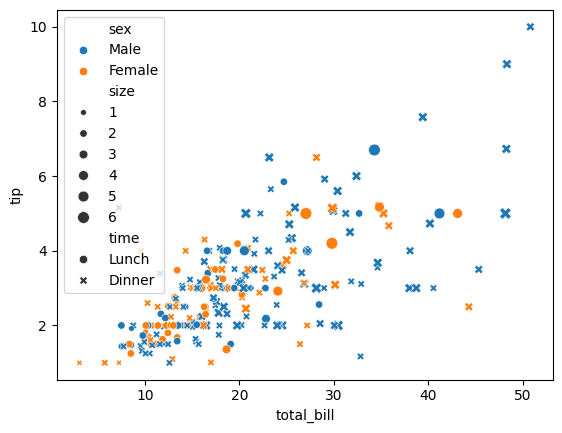

In [3]:
# Scatterplot - Axes level function

sns.scatterplot(data=tips,x='total_bill',y='tip',hue='sex',style='time',size='size')
# auto generates the legend.
# we can add additional details in the scatterplot and categorical variables.

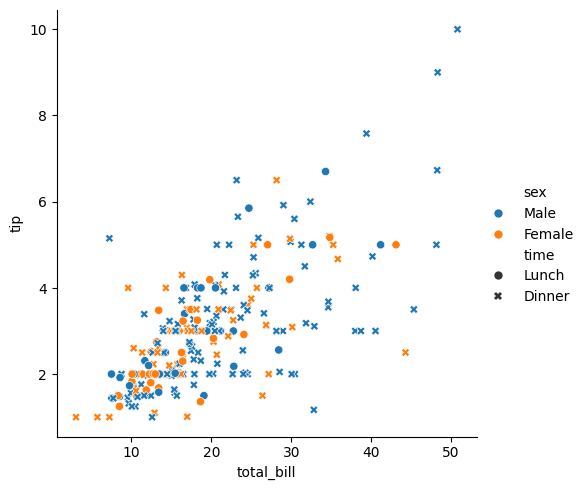

In [4]:
#Relplot -> a figure level function -> generally outputs square shaped image.

sns.relplot(data=tips, x='total_bill',y='tip',kind='scatter',hue='sex',style='time')

### Lineplot

Lineplot is just a connected scatterplot.
It is useful when we have to show continuity in our data.

- Specially useful to represent time variables.

In [5]:
# importing inbuilt dataset from plotly
gap = px.data.gapminder()
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [6]:
temp_df = gap[gap['country'] == 'India']

<Axes: xlabel='year', ylabel='lifeExp'>

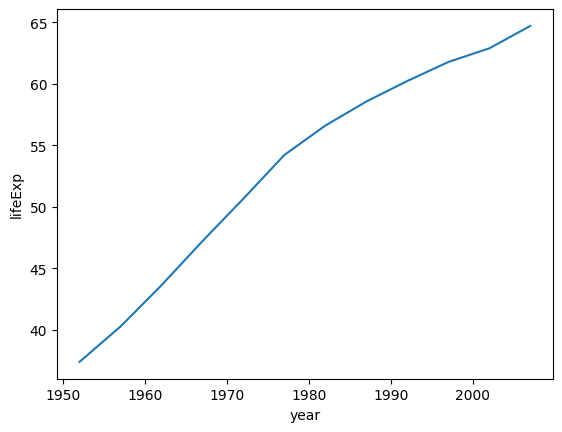

In [7]:
# axes level function

sns.lineplot(data=temp_df,x='year',y='lifeExp')

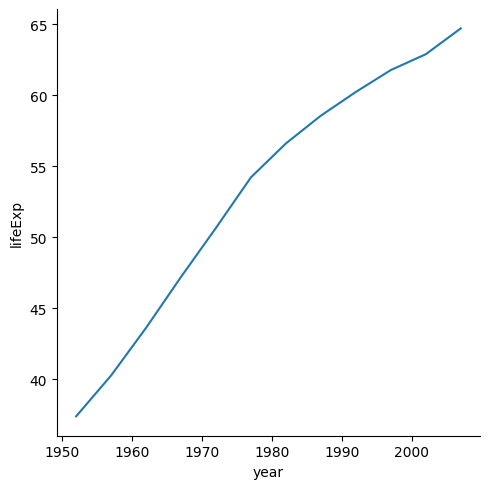

In [8]:
# plotting using figure level function - relplot

sns.relplot(data=temp_df,x='year',y='lifeExp',kind='line')

In [9]:
# hue / style

temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]

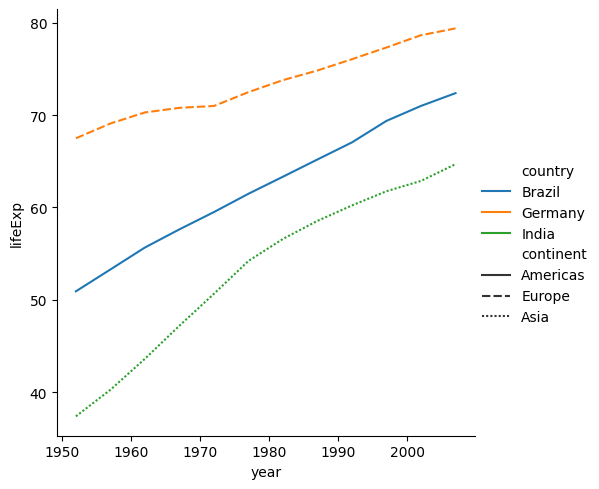

In [10]:
sns.relplot(kind='line', data=temp_df, x='year',y='lifeExp',hue='country',style='continent')

<Axes: xlabel='year', ylabel='lifeExp'>

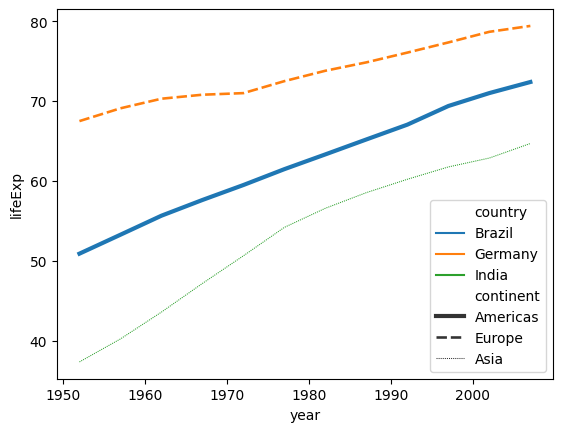

In [11]:
sns.lineplot(data=temp_df, x='year',y='lifeExp',hue='country',size='continent',style='continent')

### Facet Plot

A facet plot (also known as a small multiple or trellis plot) is a data visualization technique that splits a single chart into a grid of multiple subplots. Each subplot displays a specific subset of the data based on a categorical variable, making it easy to compare trends across different groups at a glance.

> ** Only works with figure level functions - means relplot() only, not sns.scatterplot()

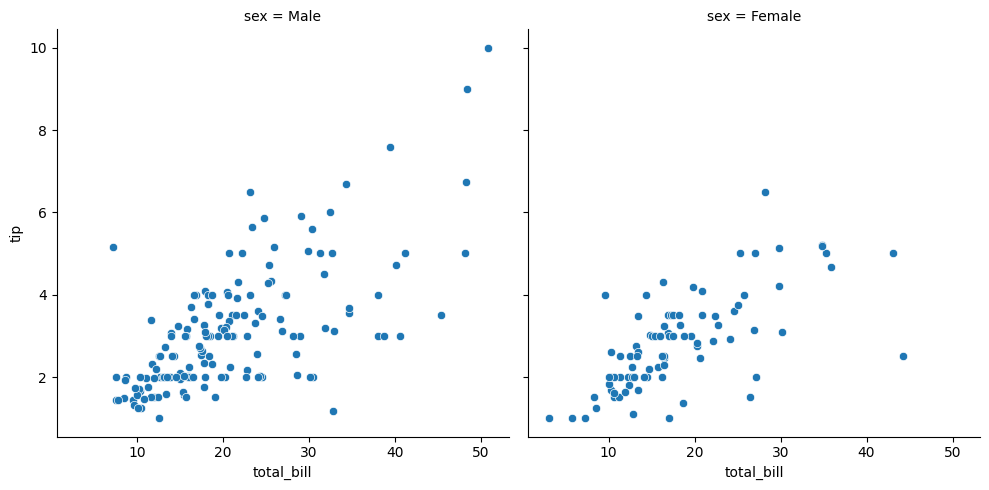

In [12]:
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='sex')

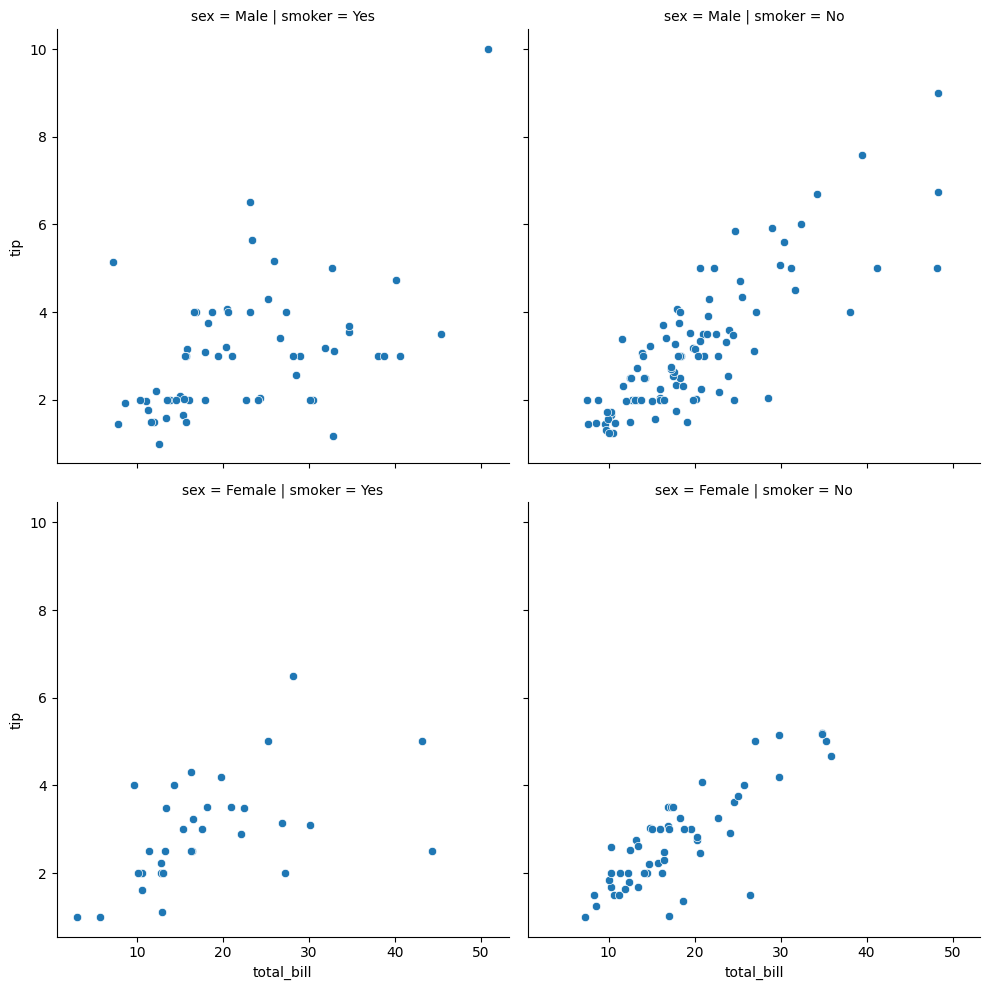

In [13]:
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='smoker',row='sex')

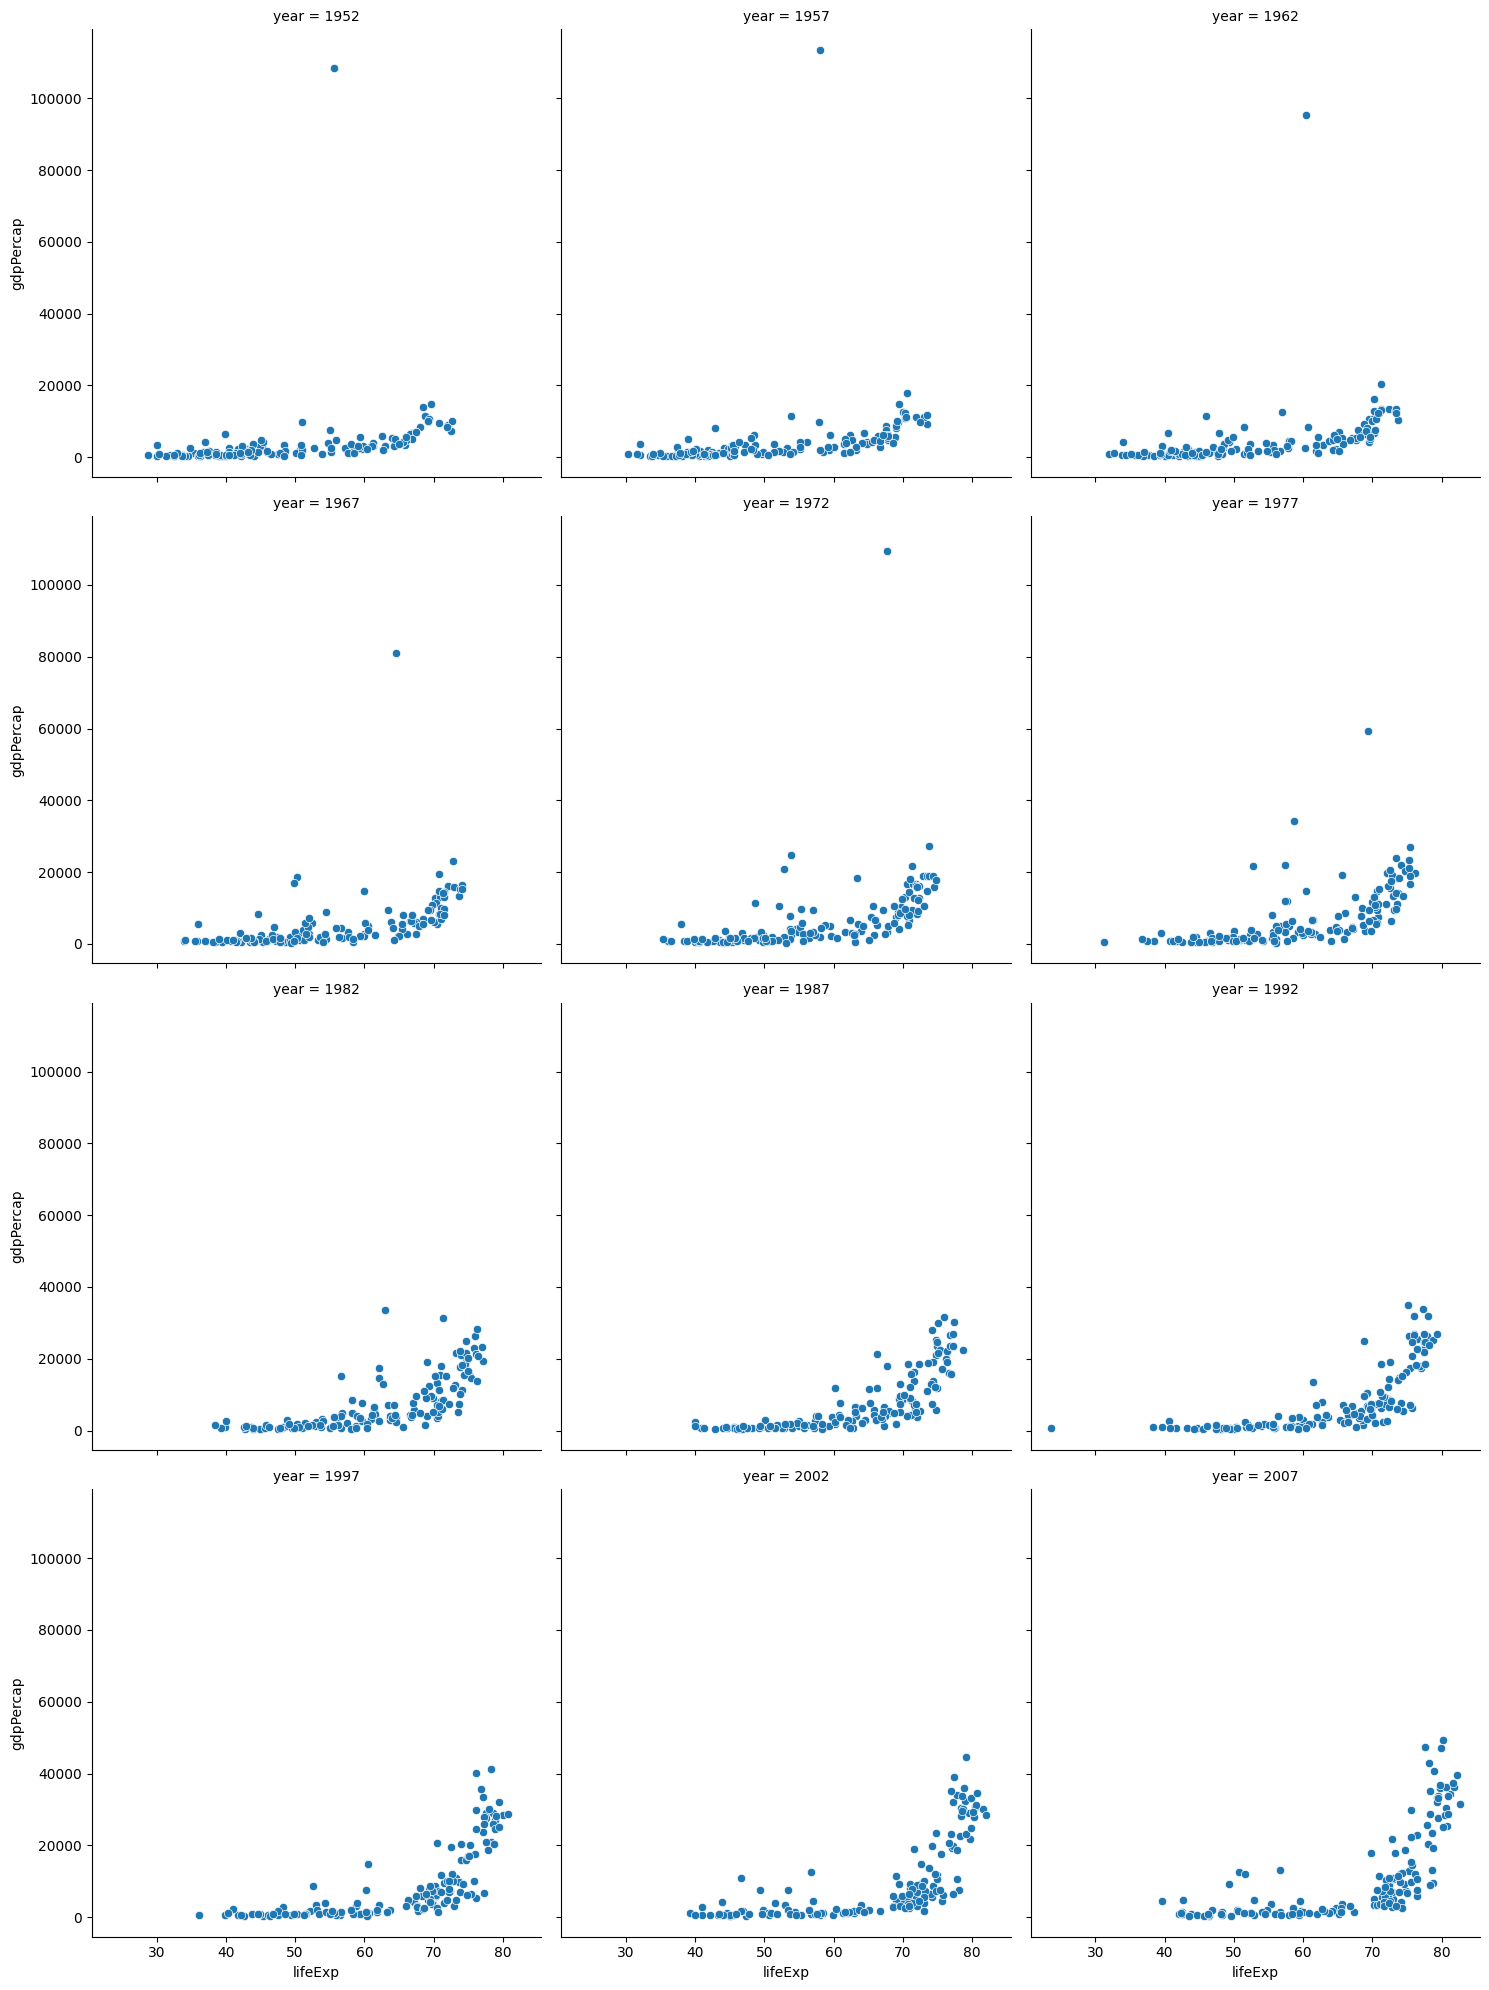

In [14]:
# col wrap

sns.relplot(data=gap,x='lifeExp',y='gdpPercap', kind='scatter',col='year', col_wrap=3)

## 2. Distribution Plots

- used for univariate analysis
- used to find out the statistical distribution
- Range of the observation
- Central Tendency
- Is the data bimodal?
- Are there outliers?

Plots under distribution plot
- histplot
- kdeplot
- rugplot

**Axes level function** - histplot(), kdeplot(), rugplot()

**Figure level function** - displot()

### Histplot  (Histogram)

<Axes: xlabel='total_bill', ylabel='Count'>

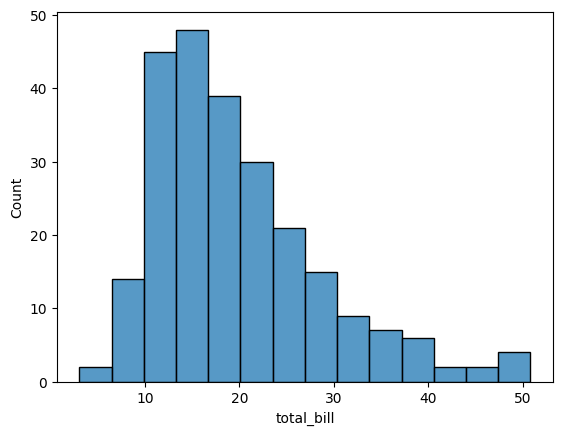

In [15]:
sns.histplot(data=tips,x='total_bill')

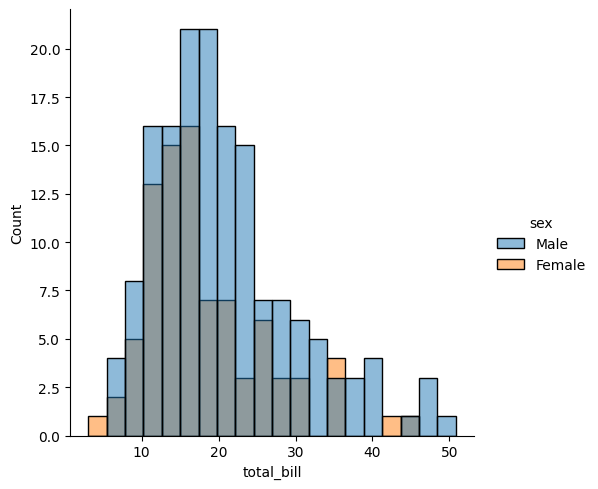

In [16]:
sns.displot(data=tips,x='total_bill',bins=20,hue='sex')

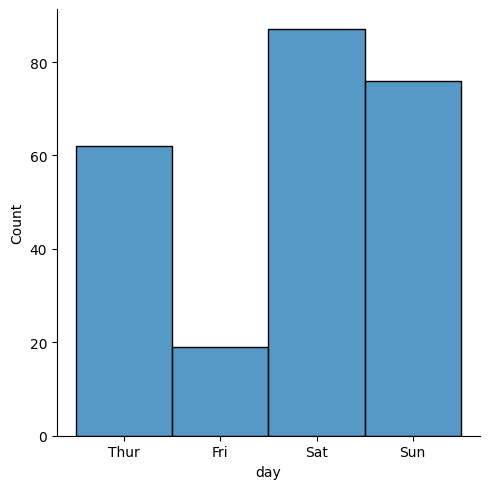

In [17]:
# plotting on a categorical column - it's more like count plot

sns.displot(data=tips,x='day',kind='hist')

In [18]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


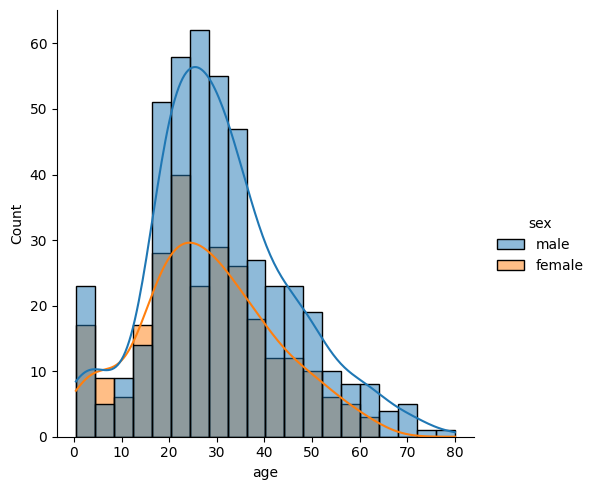

In [37]:
sns.displot(titanic,x='age',kind='hist',hue='sex',kde=True)

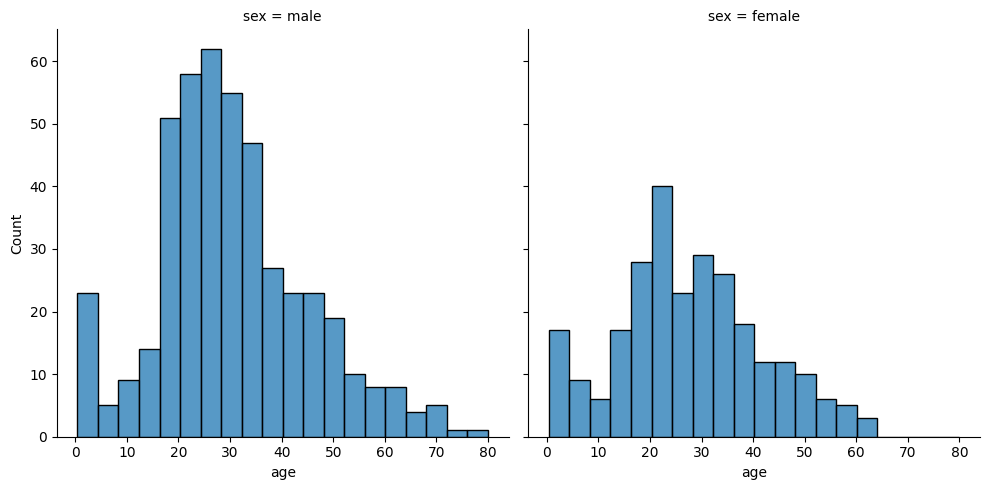

In [36]:
# facet plotting
sns.displot(titanic,x='age',kind='hist',col='sex')

### Kdeplot

Rather than using discrete bins, a kDE plot smooths the observations with a gaussian kernel, producing a contiuous density estimates.

<Axes: xlabel='total_bill', ylabel='Density'>

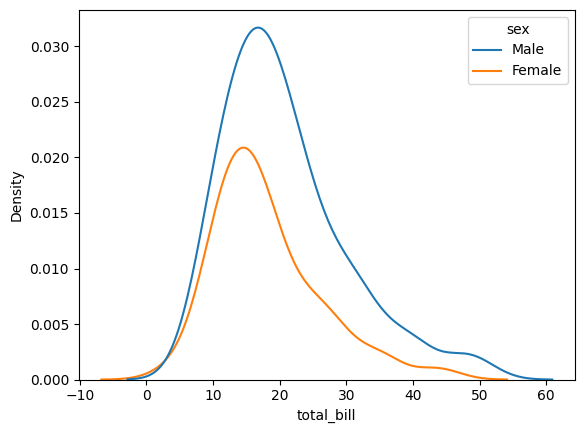

In [21]:
sns.kdeplot(data=tips,x='total_bill',hue='sex')

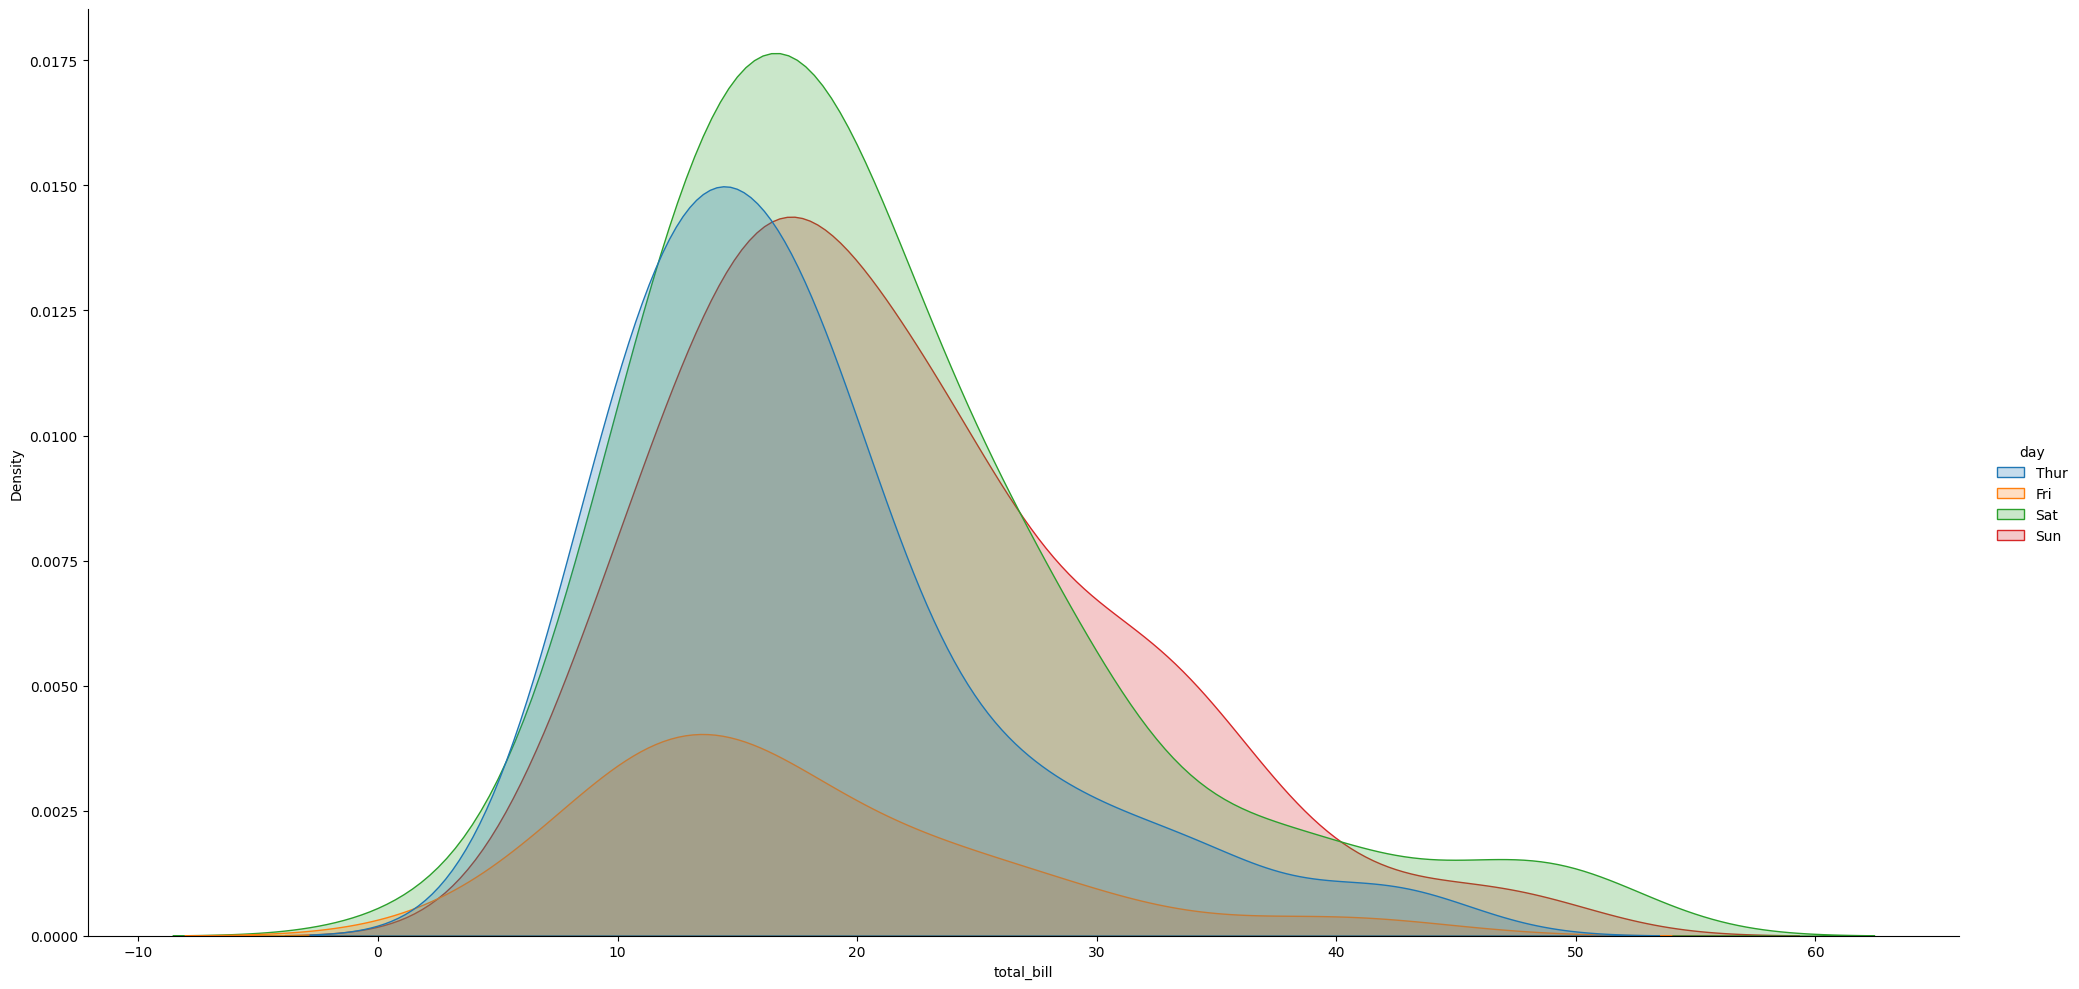

In [54]:
sns.displot(data=tips,x='total_bill',kind='kde',hue='day',fill=True,height=10,aspect=2)
# we cannot use matplotlib to change the size of figure level functions
# so we use height to change the size, and aspect ratio for width.

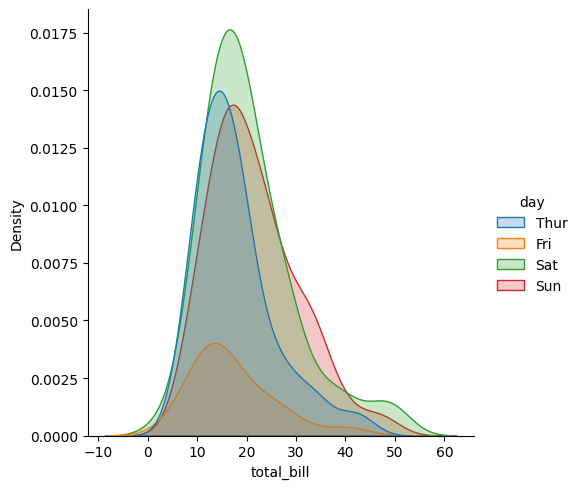

In [39]:
sns.displot(data=tips,x='total_bill',kind='kde',hue='day',fill=True)

### Rugplot

- Plot marginal distribution by drawing ticks along the x and y axes.
- This function is intended to complement other plots by showing the location of individual observations in an unobstrusive way.

A rug plot is a simple and compact data visualization that displays the exact distribution of a single quantitative variable along an axis. Instead of binning or grouping data (like a histogram), it represents every individual data point as a single perpendicular tick mark or line.

**Usecase**
- Outlier Detection
- As an Underlay
- Shows density

<Axes: xlabel='total_bill', ylabel='Density'>

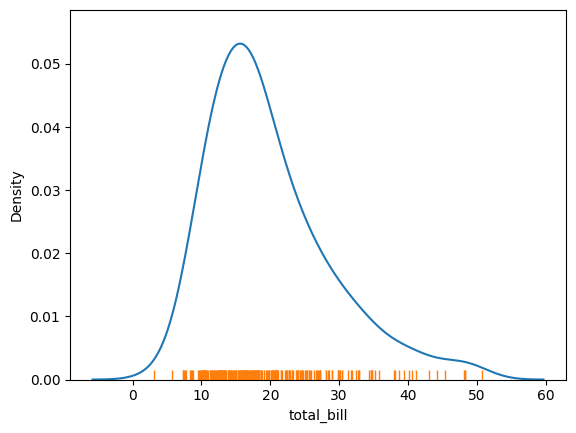

In [40]:
sns.kdeplot(data=tips,x='total_bill')
sns.rugplot(data=tips,x='total_bill')



### Bivariate Histogram

- A bivariate histogram bins the data within rectangles that tile the plot and then shows the count of observation within each rectangle with the fill color

<Axes: xlabel='total_bill', ylabel='tip'>

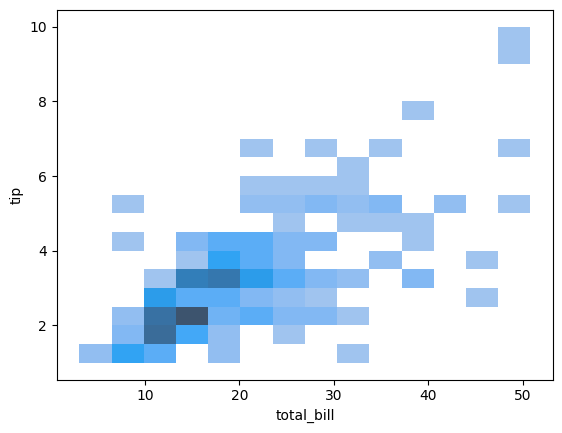

In [41]:
sns.histplot(data=tips,x='total_bill',y='tip')
# same can be done with displot.
#here darker color means more values lies there

### Bivariate Kdeplot

a bivariate KDE plot smoothes the (x,y) observations with a 2d gaussian function

<Axes: xlabel='total_bill', ylabel='tip'>

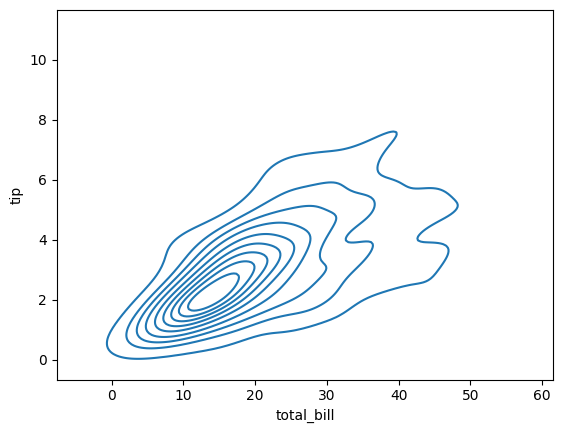

In [42]:
sns.kdeplot(data=tips,x='total_bill',y='tip')

## 3. Categorical Plot

**Categorical Scatter Plot**

- Stripplot
- Swarmplot

**Categorical Distribution Plot**

- Boxplot
- Violinplot

**Categorical Estimate Plot** For central tenedency

- Barplot
- Pointplot
- Countplot

***Figure level function - catplot()***

### Stripplot

<Axes: xlabel='day', ylabel='total_bill'>

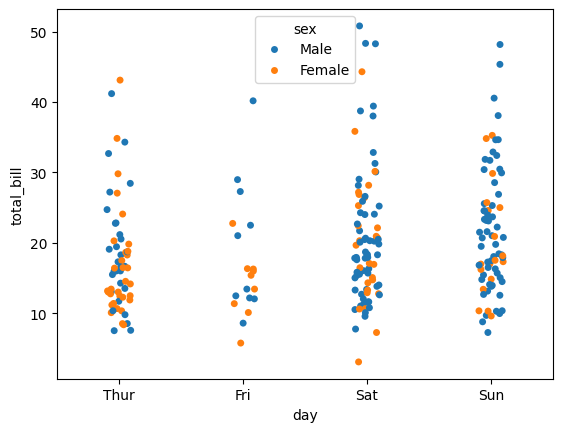

In [76]:
sns.stripplot(data=tips,x='day',y='total_bill',hue='sex')

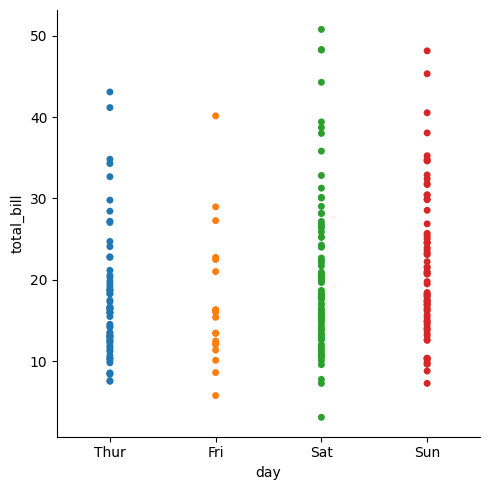

In [ ]:
# jitter = False, but plotting using figure level function catplot

sns.catplot(kind='strip',data=tips,x='day',y='total_bill',hue='day',jitter=False)
# technically it should be in a straight line, but some noise(jitter) 
# is added to increase the visibility.
# we can assign a jitter value to change the noise. jitter=0.15

### Swarmplot

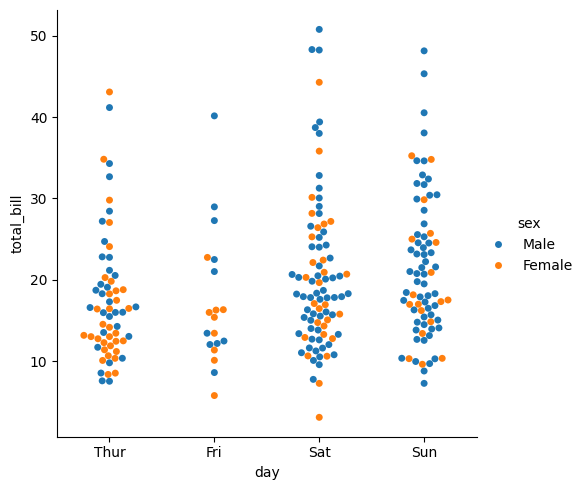

In [79]:
sns.catplot(kind='swarm',data=tips, x= 'day',y='total_bill',hue='sex') # figure level
# sns.swarmplot(data=tips, x= 'day',y='total_bill',hue='sex') #axes level

### Boxplot 

<Axes: ylabel='total_bill'>

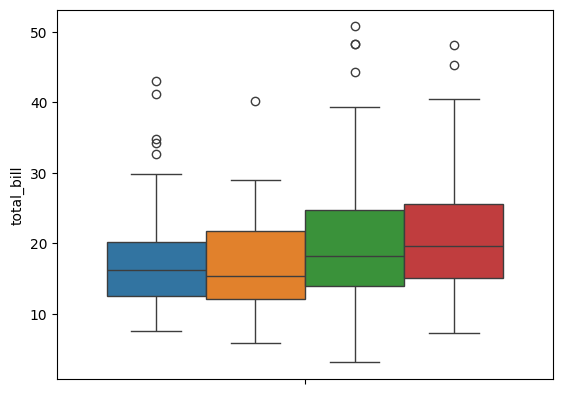

In [91]:
sns.boxplot(data=tips,y='total_bill',hue='day',legend=False)
# sns.catplot(kind='box',data=tips,y='total_bill',hue='day',legend=False)

### Violinplot = [Boxplot + KDEplot]

<Axes: xlabel='day', ylabel='total_bill'>

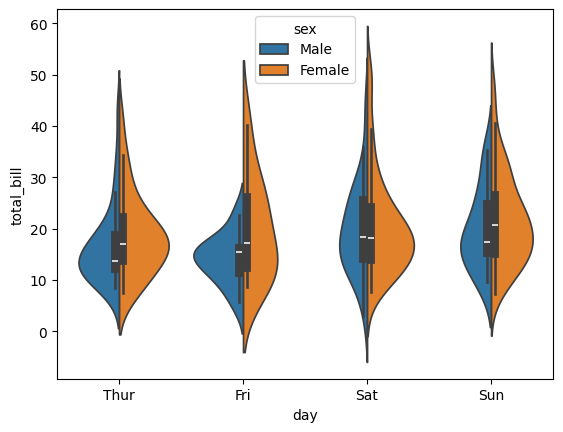

In [96]:
sns.violinplot(data=tips,x='day',y='total_bill',hue='sex',split=True)

# sns.catplot(kind='violin',data=tips,y='total_bill',hue='day',legend=False)

## 4. Matrix Plot

- Heatmap
- Clustermap

### Heatmap

- Plot rectangular data as a color-encoded matrix

In [43]:
# Lets work on the gap dataset, but first lets 
# convert he long data to wide data by pivoting it.

temp_df = gap.pivot(index='country',columns='year',values='lifeExp')
temp_df.head()

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
country,,,,,,,,,,,,
Afghanistan,28.801,30.332,31.997,34.020,36.088,38.438,39.854,40.822,41.674,41.763,42.129,43.828
Albania,55.230,59.280,64.820,66.220,67.690,68.930,70.420,72.000,71.581,72.950,75.651,76.423
Algeria,43.077,45.685,48.303,51.407,54.518,58.014,61.368,65.799,67.744,69.152,70.994,72.301
Angola,30.015,31.999,34.000,35.985,37.928,39.483,39.942,39.906,40.647,40.963,41.003,42.731
Argentina,62.485,64.399,65.142,65.634,67.065,68.481,69.942,70.774,71.868,73.275,74.340,75.320


<Axes: xlabel='year', ylabel='country'>

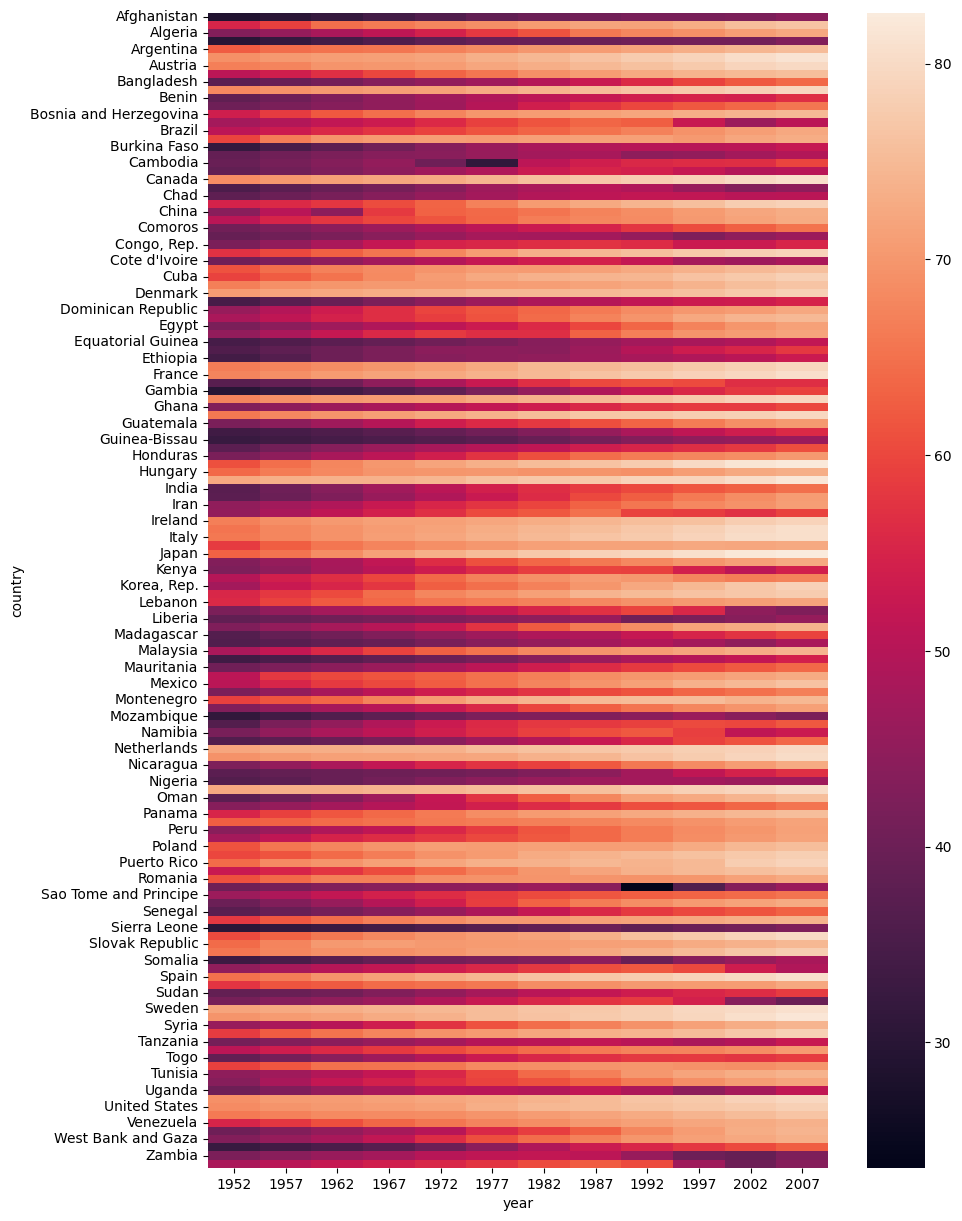

In [44]:
# heatmap only has an axes level function
plt.figure(figsize=(10,15))
sns.heatmap(temp_df)


In [45]:
# annot parameter - to see the value as well

temp_eu = gap[gap['continent'] == 'Europe'].pivot(index='country',columns='year',values='lifeExp')

<Axes: xlabel='year', ylabel='country'>

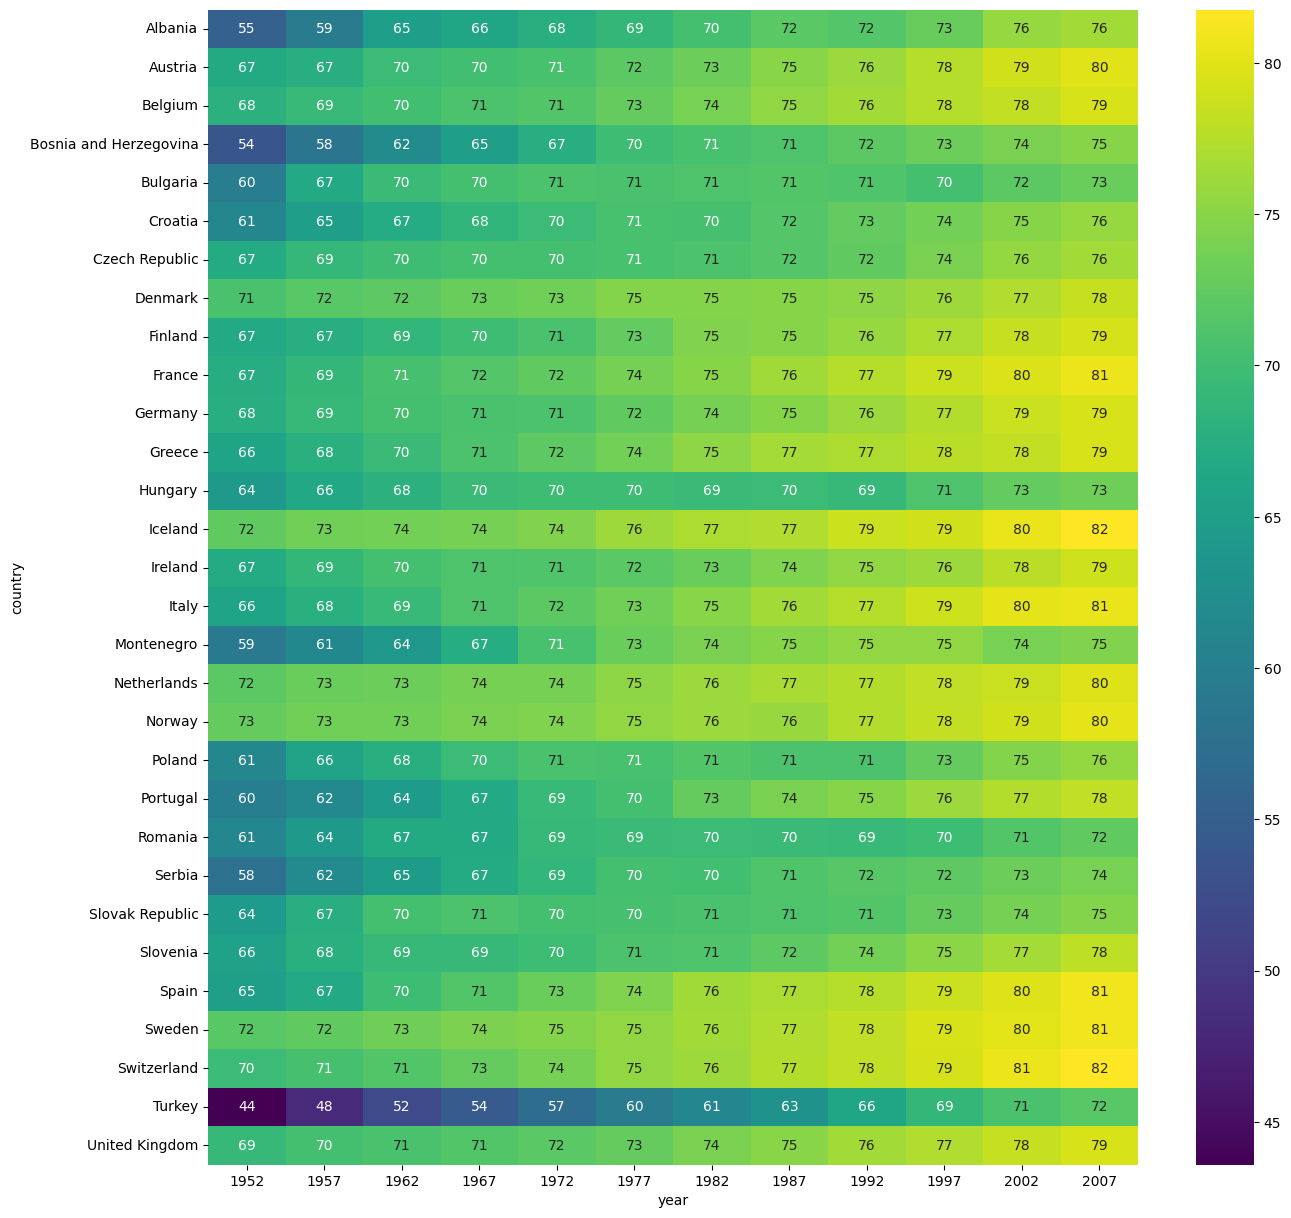

In [46]:
plt.figure(figsize=(15,15)) # always change the size before generating the graph


sns.heatmap(temp_eu,annot=True,cmap='viridis')

### Clustermap

- Similar to heatmap, but is plots a matrix dataset as a hierarchically-clustered heatmap.

- This function requires scipy to be available.

In [48]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


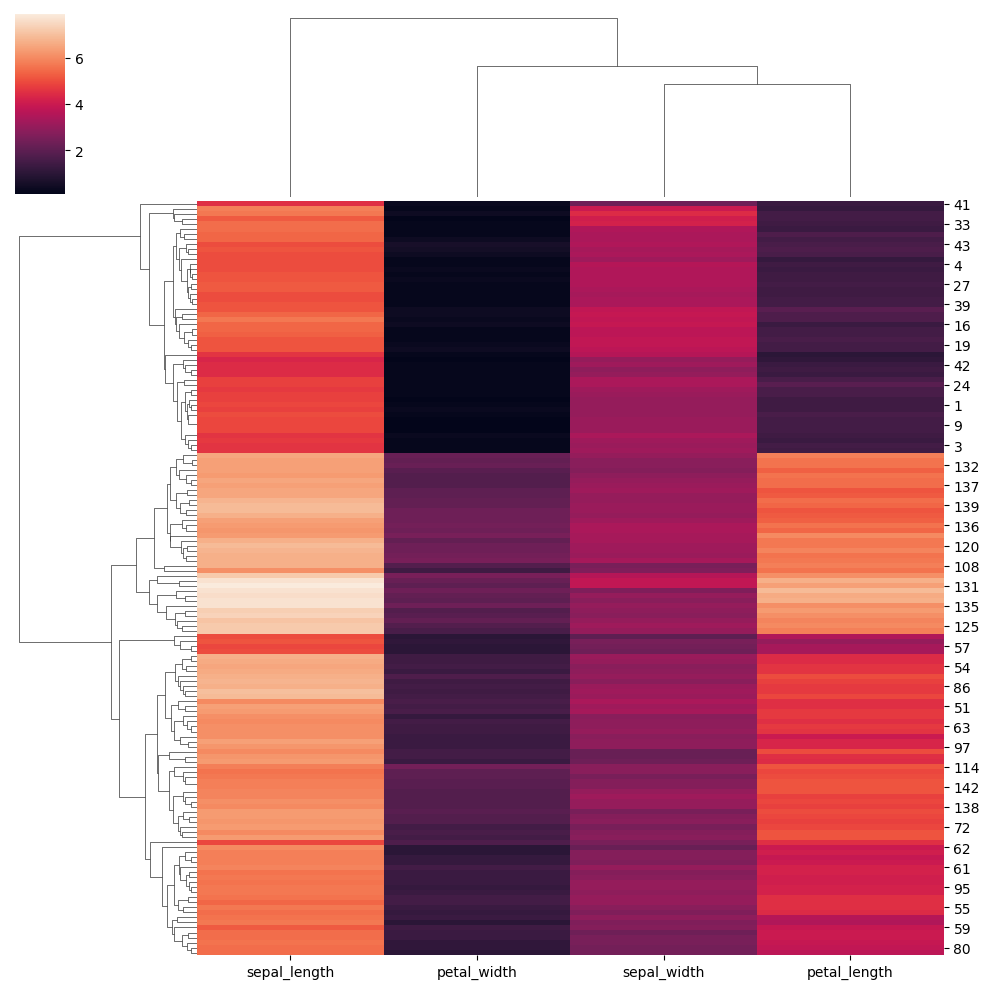

In [55]:
sns.clustermap(iris.iloc[:,[0,1,2,3]])

## 5. 